# With statevector

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import XGate, ZGate
import numpy as np
import matplotlib.pyplot as plt

# Matplotlib style
from qbstyles import mpl_style
mpl_style(dark=False)

In [2]:
# Parameters
dt = 0.001
w2 = 9.8
x0 = np.pi/2
y0 = 1.0
n_steps = 5000

# Function to create the circuit
def circuit(theta_init):
    qc = QuantumCircuit(3)
    # Prepare initial state in q1: RY(theta_init)
    qc.ry(theta_init, 1)

    # LCU parameters for general omega
    b = dt * (1 - w2) / 2
    c = dt * (1 + w2) / 2
    c0 = 1.0
    c1 = np.abs(b)
    c2 = c
    alpha_lcu = c0 + c1 + c2
    sign_x = np.sign(b) if b != 0 else 1
    p0 = c0 / alpha_lcu
    p1 = c1 / alpha_lcu
    p2 = c2 / alpha_lcu

    # State preparation on ancillas q0 and q2
    theta_q0 = 2 * np.arcsin(np.sqrt(p2))
    qc.ry(theta_q0, 0)
    p_sum = p0 + p1
    theta_q2 = 2 * np.arcsin(np.sqrt(p1 / p_sum) if p_sum > 0 else 0)
    qc.x(0)
    qc.cry(theta_q2, 0, 2)
    qc.x(0)

    # Select V
    # U1 on |01> (q0=0, q2=1): X or -X (= Z X Z)
    qc.x(0)
    if sign_x == 1:
        ccrx = XGate().control(num_ctrl_qubits=2, ctrl_state='11')
        qc.append(ccrx, [0, 2, 1])
    else:
        ccrz = ZGate().control(num_ctrl_qubits=2, ctrl_state='11')
        ccrx = XGate().control(num_ctrl_qubits=2, ctrl_state='11')
        qc.append(ccrz, [0, 2, 1])
        qc.append(ccrx, [0, 2, 1])
        qc.append(ccrz, [0, 2, 1])
    qc.x(0)

    # U2 on |10> (q0=1, q2=0): Z X (= [[0,1],[-1,0]])
    qc.x(2)
    ccrx = XGate().control(num_ctrl_qubits=2, ctrl_state='11')
    qc.append(ccrx, [0, 2, 1])
    ccrz = ZGate().control(num_ctrl_qubits=2, ctrl_state='11')
    qc.append(ccrz, [0, 2, 1])
    qc.x(2)

    # Inverse preparation
    qc.x(0)
    qc.cry(-theta_q2, 0, 2)
    qc.x(0)
    qc.ry(-theta_q0, 0)

    return qc, alpha_lcu

# Simulation and extraction
def next_step(x_current, y_current):
    norm_v = np.sqrt(x_current**2 + y_current**2)
    if norm_v == 0:
        return 0, 0
    theta_init = 2 * np.arctan2(y_current, x_current)

    qc, alpha_lcu = circuit(theta_init)

    # Simulate statevector (exact)
    state = Statevector(qc)
    amps = state.data

    # Post-selection q0=0, q2=0: amps[0] (|000>), amps[2] (|010>)
    projected_x = amps[0]
    projected_y = amps[2]

    x_new = np.real(projected_x * alpha_lcu * norm_v)
    y_new = np.real(projected_y * alpha_lcu * norm_v)

    return x_new, y_new

trajectory = []
x_current = x0
y_current = y0
trajectory.extend([x_current, y_current])

for step in range(n_steps):
    x_new, y_new = next_step(x_current, y_current)
    trajectory.extend([x_new, y_new])
    x_current = x_new
    y_current = y_new

# print("Statevector (x0, y0, x1, y1, ..., xn, yn):", trajectory)

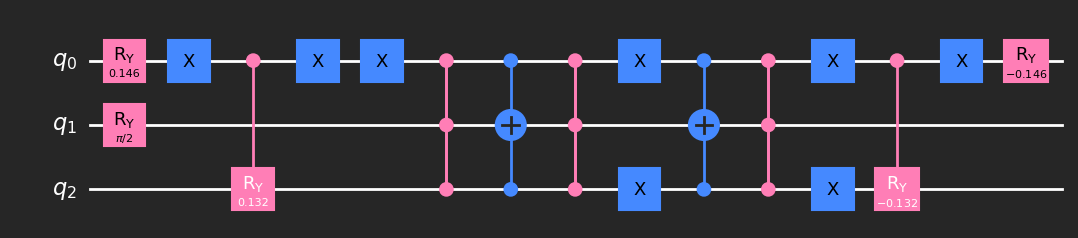

In [3]:
# Draw an example circuit
example_qc, _ = circuit(np.pi/2)
example_qc.draw('mpl', style='iqp-dark')

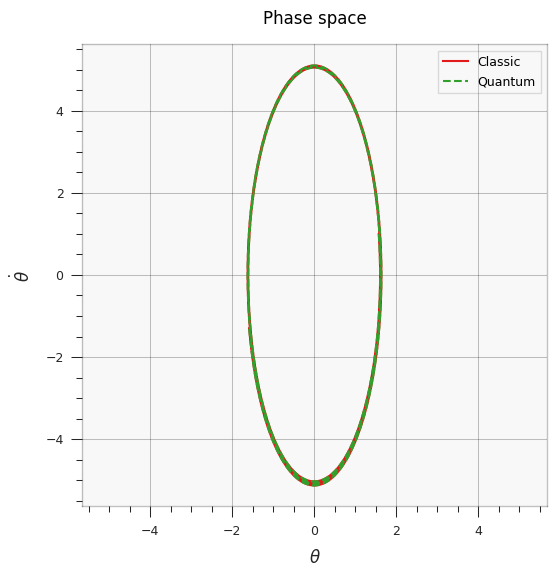

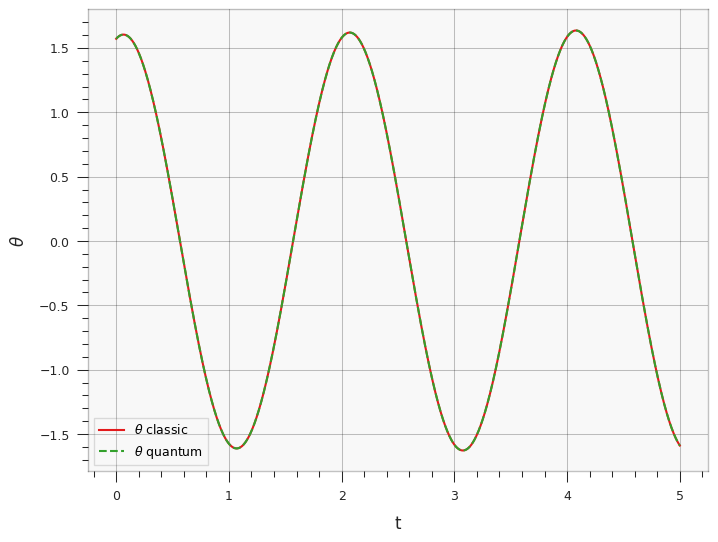

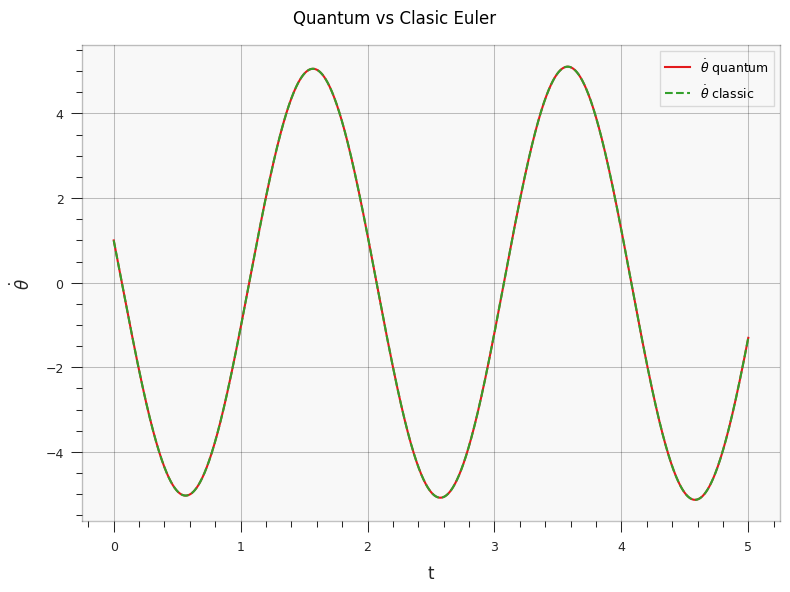

In [16]:
# Classic
t_values = [i * dt for i in range(n_steps + 1)]
x_euler = np.zeros_like(t_values)
y_euler = np.zeros_like(t_values)
x_euler[0] = x0
y_euler[0] = y0

# Euler step update:
for n in range(n_steps):
    x_euler[n+1] = x_euler[n] + dt * y_euler[n]
    y_euler[n+1] = y_euler[n] + dt * (-w2 * x_euler[n])

x_quantum = trajectory[0::2]
y_quantum = trajectory[1::2]

plt.figure(figsize=(6,6))
plt.plot(x_quantum, y_quantum, label="Classic")
plt.plot(x_euler, y_euler,'--', label="Quantum")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\dot \theta$")
plt.title("Phase space")
plt.legend()
plt.grid(True)
plt.axis("equal")

plt.figure(figsize=(8,6))
# plt.subplot(1,2,1)
plt.plot(t_values, x_quantum, label=r"$\theta$ classic")
plt.plot(t_values, x_euler,'--', label=r"$\theta$ quantum")
plt.xlabel("t")
plt.ylabel(r"$\theta$")
plt.legend()
plt.grid(True)

plt.figure(figsize=(8,6))
# plt.subplot(1,2,2)
plt.plot(t_values, y_quantum,label=r"$\dot \theta$ quantum")
plt.plot(t_values, y_euler, '--', label=r"$\dot \theta$ classic")
plt.xlabel("t")
plt.ylabel(r"$\dot \theta$")
plt.legend()
plt.grid(True)

plt.suptitle("Quantum vs Clasic Euler")
plt.tight_layout()
plt.show()

# With measurements

## Lineal

In [ ]:
from qiskit_aer import AerSimulator

dt = 0.001
w2 = 9.8
w = np.sqrt(w2)  # For classical solution
x0 = np.pi / 4
y0 = 1.0
n_steps = 3200
shots = 30000  # Number of shots for measurements

# Function to create the circuit
def circuit(theta_init):
    qc = QuantumCircuit(3)
    # Prepare initial state in q1: RY(theta_init)
    qc.ry(theta_init, 1)

    # LCU parameters for general omega
    b = dt * (1 - w2) / 2
    c = dt * (1 + w2) / 2
    c0 = 1.0
    c1 = np.abs(b)
    c2 = c
    alpha_lcu = c0 + c1 + c2
    if alpha_lcu == 0:
        raise ValueError("LCU normalization factor alpha_lcu is zero")
    
    sign_x = np.sign(b) if b != 0 else 1
    p0 = c0 / alpha_lcu
    p1 = c1 / alpha_lcu
    p2 = c2 / alpha_lcu

    # State preparation on ancillas q0 and q2
    theta_q0 = 2 * np.arcsin(np.sqrt(p2))
    qc.ry(theta_q0, 0)
    p_sum = p0 + p1
    theta_q2 = 2 * np.arcsin(np.sqrt(p1 / p_sum) if p_sum > 0 else 0)
    qc.x(0)
    qc.cry(theta_q2, 0, 2)
    qc.x(0)

    # Select V
    # U1 on |01> (q0=0, q2=1): X or -X (= Z X Z)
    qc.x(0)
    if sign_x == 1:
        ccrx = XGate().control(num_ctrl_qubits=2, ctrl_state='11')
        qc.append(ccrx, [0, 2, 1])
    else:
        ccrz = ZGate().control(num_ctrl_qubits=2, ctrl_state='11')
        ccrx = XGate().control(num_ctrl_qubits=2, ctrl_state='11')
        qc.append(ccrz, [0, 2, 1])
        qc.append(ccrx, [0, 2, 1])
        qc.append(ccrz, [0, 2, 1])
    qc.x(0)

    # U2 on |10> (q0=1, q2=0): Z X
    qc.x(2)
    ccrx = XGate().control(num_ctrl_qubits=2, ctrl_state='11')
    qc.append(ccrx, [0, 2, 1])
    ccrz = ZGate().control(num_ctrl_qubits=2, ctrl_state='11')
    qc.append(ccrz, [0, 2, 1])
    qc.x(2)

    # Inverse preparation
    qc.x(0)
    qc.cry(-theta_q2, 0, 2)
    qc.x(0)
    qc.ry(-theta_q0, 0)

    return qc, alpha_lcu

# Simulation and extraction with measurements
def next_step(x_current, y_current):
    norm_v = np.sqrt(x_current**2 + y_current**2)
    if norm_v < 1e-10:  # Avoid division by zero
        print("Warning: State norm is near zero, returning current state")
        return x_current, y_current
    theta_init = 2 * np.arctan2(y_current, x_current)

    qc, alpha_lcu = circuit(theta_init)
    backend = AerSimulator()

    # Z basis measurement
    qc_z = qc.copy()
    qc_z.measure_all()
    result_z = backend.run(qc_z, shots=shots).result()
    counts_z = result_z.get_counts()
    c000 = counts_z.get('000', 0)
    c010 = counts_z.get('010', 0)
    succ_z = c000 + c010
    if succ_z < 10:  # Avoid poor statistics
        print("Warning: Too few successful Z measurements, returning current state")
        return x_current, y_current
    p_succ = succ_z / shots
    cond_p0 = c000 / succ_z  # P(0) in post-selected subspace
    cond_p1 = c010 / succ_z  # P(1) in post-selected subspace

    # X basis measurement
    qc_x = qc.copy()
    qc_x.h(1)  # Hadamard on q1 for X basis
    qc_x.measure_all()
    result_x = backend.run(qc_x, shots=shots).result()
    counts_x = result_x.get_counts()
    c000_x = counts_x.get('000', 0)
    c010_x = counts_x.get('010', 0)
    succ_x = c000_x + c010_x
    if succ_x < 10:
        print("Warning: Too few successful X measurements, returning current state")
        return x_current, y_current
    cond_px = c000_x / succ_x  # P(+1) in X basis
    x_exp = 2 * cond_px - 1  # <X> = P(+1) - P(-1)

    # Reconstruct amplitudes
    abs_a = np.sqrt(cond_p0)
    abs_b = np.sqrt(cond_p1)
    computed_ab = x_exp / 2  # <X> = 2 * Re(a*b)
    rel_sign = 1 if computed_ab >= 0 else -1

    # Candidate states
    a = abs_a
    b = rel_sign * abs_b
    scaling = alpha_lcu * norm_v * np.sqrt(p_succ)

    x_candidate1 = a * scaling
    y_candidate1 = b * scaling
    x_candidate2 = -a * scaling
    y_candidate2 = -b * scaling

    # Choose based on continuity (dot product)
    dot1 = x_candidate1 * x_current + y_candidate1 * y_current
    dot2 = x_candidate2 * x_current + y_candidate2 * y_current

    if dot1 >= dot2:
        return x_candidate1, y_candidate1
    else:
        return x_candidate2, y_candidate2

# Compute trajectory
trajectory = [(x0, y0)]
x_current = x0
y_current = y0

for step in range(n_steps):
    # print(step)
    x_new, y_new = next_step(x_current, y_current)
    trajectory.append((x_new, y_new))
    x_current, y_current = x_new, y_new

# Extract positions and velocities
positions_q, velocities_q = zip(*trajectory)

# Compute classical trajectory (harmonic oscillator)
t_values = np.arange(0, (n_steps + 1) * dt, dt)
positions_cl = x0 * np.cos(w * t_values) + (y0 / w) * np.sin(w * t_values)
velocities_cl = y0 * np.cos(w * t_values) - w * x0 * np.sin(w * t_values)

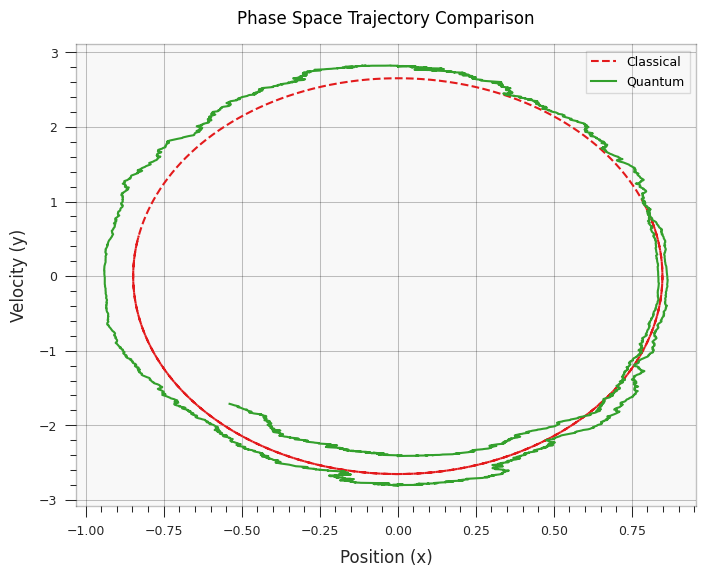

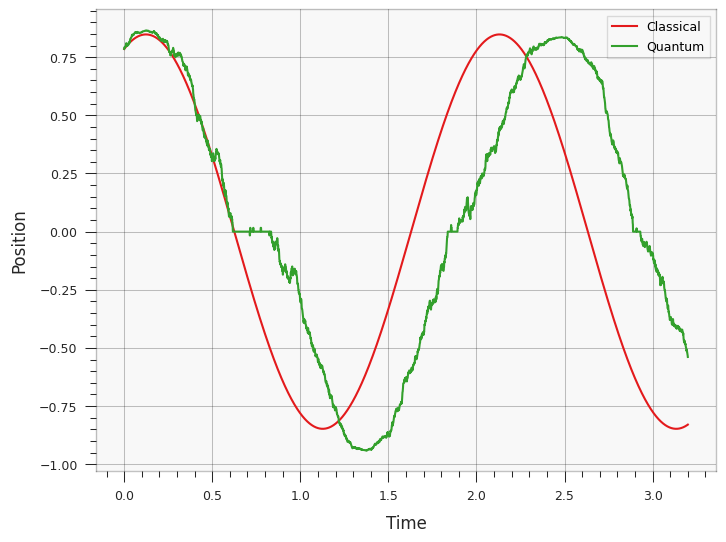

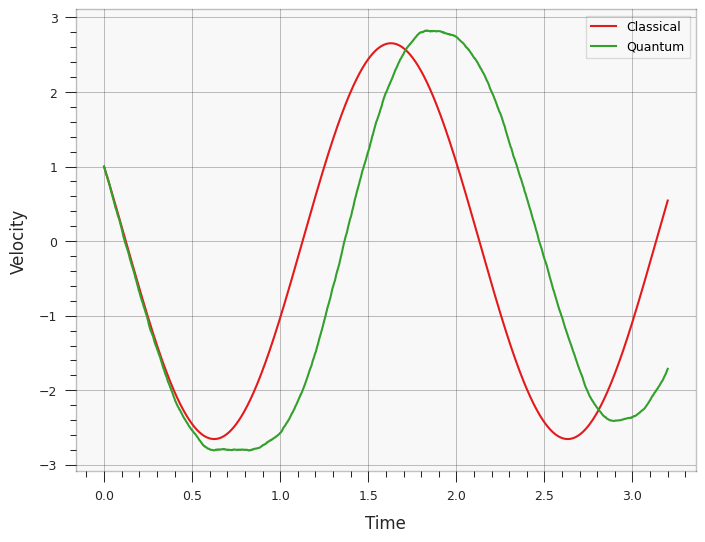

In [20]:

# Plot phase space trajectory
plt.figure(figsize=(8, 6))
plt.plot(positions_cl, velocities_cl, label='Classical', linestyle='--')
plt.plot(positions_q, velocities_q, label='Quantum')
plt.xlabel('Position (x)')
plt.ylabel('Velocity (y)')
plt.title('Phase Space Trajectory Comparison')
plt.legend()
plt.grid(True)
plt.show()

# Plot time series for comparison
plt.figure(figsize=(8, 6))
# plt.subplot(1, 2, 1)
plt.plot(t_values, positions_cl, label='Classical')
plt.plot(t_values, positions_q, label='Quantum')
plt.xlabel('Time')
plt.ylabel('Position')
plt.legend()
plt.grid(True)

plt.figure(figsize=(8, 6))
# plt.subplot(1, 2, 2)
plt.plot(t_values, velocities_cl, label='Classical')
plt.plot(t_values, velocities_q, label='Quantum')
plt.xlabel('Time')
plt.ylabel('Velocity')
plt.legend()
plt.grid(True)
plt.show()

## Lineal (Symmetric case $\omega =1$)

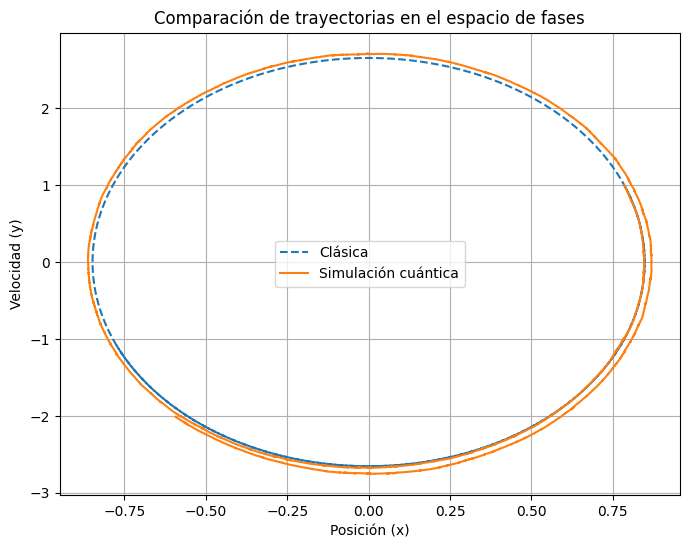

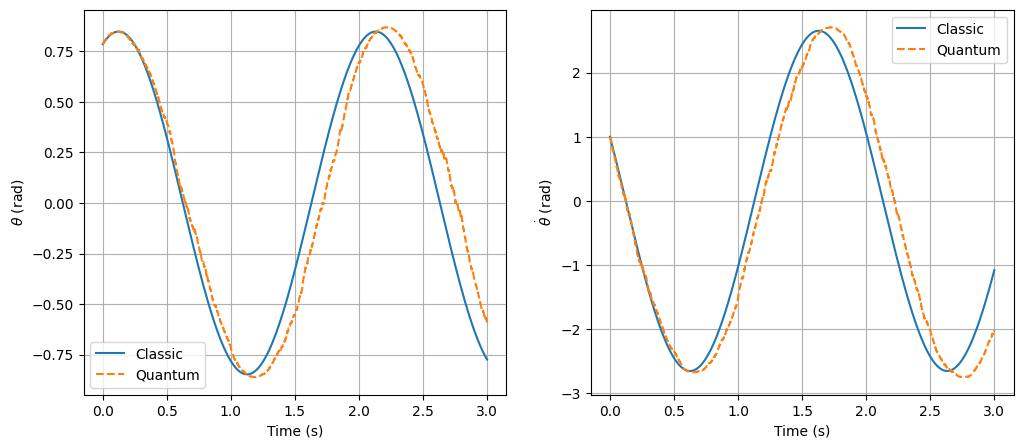

In [ ]:
dt = 0.001  
w2 = 1
w = np.sqrt(w2)
x0 = np.pi / 4
y0 = 1.0 / w  # Rescaled initial y
n_steps = 3000  
shots = 20000  

# Modified circuit for rescaled (symmetric case)
def circuit(theta_init):
    qc = QuantumCircuit(3)
    # Prepare initial state in q1: RY(theta_init)
    qc.ry(theta_init, 1)

    # LCU parameters for symmetric case (effective w2=1, dt_param = dt * w)
    dt_param = dt * w
    b = 0.0  # (1 - 1)/2 = 0
    c = dt_param  # Effective dt_param
    c0 = 1.0
    c1 = np.abs(b)
    c2 = c
    alpha_lcu = c0 + c1 + c2
    sign_x = 1  # since b=0
    p0 = c0 / alpha_lcu
    p1 = c1 / alpha_lcu
    p2 = c2 / alpha_lcu

    # State preparation on ancillas q0 and q2
    # Since p1=0, theta_q2=0, no entanglement with q2
    theta_q0 = 2 * np.arcsin(np.sqrt(p2))
    qc.ry(theta_q0, 0)
    # Skip cry since theta_q2=0

    # Select V
    # Skip U1 since p1=0

    # U2 on |10> (q0=1, q2=0): Z X
    qc.x(2)
    ccrx = XGate().control(num_ctrl_qubits=2, ctrl_state='11')
    qc.append(ccrx, [0, 2, 1])
    ccrz = ZGate().control(num_ctrl_qubits=2, ctrl_state='11')
    qc.append(ccrz, [0, 2, 1])
    qc.x(2)

    # Inverse preparation
    # Skip inverse cry
    qc.ry(-theta_q0, 0)

    return qc, alpha_lcu

# next_step with Z and X measurements
def next_step(x_current, y_current):
    norm_v = np.sqrt(x_current**2 + y_current**2)
    if norm_v == 0:
        return 0, 0
    theta_init = 2 * np.arctan2(y_current, x_current)

    qc, alpha_lcu = circuit(theta_init)

    backend = AerSimulator()

    # Z basis measurement
    qc_z = qc.copy()
    qc_z.measure_all()
    result_z = backend.run(qc_z, shots=shots).result()
    counts_z = result_z.get_counts()
    c000 = counts_z.get('000', 0)
    c010 = counts_z.get('010', 0)
    succ_z = c000 + c010
    if succ_z < 10:  
        return x_current, y_current
    p_succ = succ_z / shots
    cond_p0 = c000 / succ_z
    cond_p1 = c010 / succ_z

    # X basis measurement (H on q1)
    qc_x = qc.copy()
    qc_x.h(1)
    qc_x.measure_all()
    result_x = backend.run(qc_x, shots=shots).result()
    counts_x = result_x.get_counts()
    c000_x = counts_x.get('000', 0)
    c010_x = counts_x.get('010', 0)
    succ_x = c000_x + c010_x
    if succ_x < 10:
        return x_current, y_current
    cond_px = c000_x / succ_x  # P(+)
    x_exp = 2 * cond_px - 1  # <X>

    # Reconstruct amplitudes (normalized post-selected)
    abs_a = np.sqrt(cond_p0)
    abs_b = np.sqrt(cond_p1)
    computed_ab = x_exp / 2
    rel_sign = 1 if computed_ab >= 0 else -1

    # Candidate with positive a
    a = abs_a
    b = rel_sign * abs_b

    scaling = alpha_lcu * norm_v * np.sqrt(p_succ)

    x_candidate1 = a * scaling
    y_candidate1 = b * scaling
    x_candidate2 = -a * scaling
    y_candidate2 = -b * scaling

    # Choose based on continuity (dot product)
    dot1 = x_candidate1 * x_current + y_candidate1 * y_current
    dot2 = x_candidate2 * x_current + y_candidate2 * y_current

    if dot1 >= dot2:
        return x_candidate1, y_candidate1
    else:
        return x_candidate2, y_candidate2

# Compute trajectory
trajectory = []
x_current = x0
y_current = y0
trajectory.extend([x_current, y_current])
for step in range(n_steps):
    x_new, y_new = next_step(x_current, y_current)
    trajectory.extend([x_new, y_new])
    x_current = x_new
    y_current = y_new

# Rescale back y to physical
for i in range(1, len(trajectory), 2):
    trajectory[i] *= w

positions_q = trajectory[::2]
velocities_q = trajectory[1::2]

# Classic solution
t_values = np.arange(0, (n_steps + 1) * dt, dt)
positions_cl = x0 * np.cos(w * t_values) + y0 * np.sin(w * t_values)
velocities_cl = 1.0 * np.cos(w * t_values) - w * x0 * np.sin(w * t_values)

plt.figure(figsize=(8, 6))
plt.plot(positions_cl, velocities_cl, label='Clásica', linestyle='--')
plt.plot(positions_q, velocities_q, label='Simulación cuántica')
plt.xlabel('Posición (x)')
plt.ylabel('Velocidad (y)')
plt.title('Comparación de trayectorias en el espacio de fases')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(t_values, positions_cl, label='Classic')
plt.plot(t_values, positions_q, '--', label='Quantum')
plt.xlabel('Time (s)')
plt.ylabel(r'$\theta$ (rad)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(t_values, velocities_cl, label='Classic')
plt.plot(t_values, velocities_q, '--', label='Quantum')
plt.xlabel('Time (s)')
plt.ylabel(r'$\dot \theta$ (rad)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import XGate, ZGate
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

# Parameters
dt = 0.001
w2 = 9.8
w = np.sqrt(w2)
x0 = np.pi / 2
y0 = 1.0 / w  # Rescaled initial y
n_steps = 3000  # Match second code
shots = 20000

# Function to create the circuit (symmetric case)
def circuit(theta_init):
    qc = QuantumCircuit(3)
    # Prepare initial state in q1: RY(theta_init)
    qc.ry(theta_init, 1)

    # LCU parameters for symmetric case
    dt_param = dt * w
    b = 0.0  # Simplified dynamics
    c = dt_param
    c0 = 1.0
    c1 = np.abs(b)
    c2 = c
    alpha_lcu = c0 + c1 + c2
    if alpha_lcu == 0:
        raise ValueError("LCU normalization factor alpha_lcu is zero")
    
    sign_x = 1  # Arbitrary since b=0
    p0 = c0 / alpha_lcu
    p1 = c1 / alpha_lcu
    p2 = c2 / alpha_lcu

    # State preparation on ancillas q0 (p1=0 simplifies circuit)
    theta_q0 = 2 * np.arcsin(np.sqrt(p2))
    qc.ry(theta_q0, 0)

    # Select V (only U2 since p1=0)
    qc.x(2)
    ccrx = XGate().control(num_ctrl_qubits=2, ctrl_state='11')
    qc.append(ccrx, [0, 2, 1])
    ccrz = ZGate().control(num_ctrl_qubits=2, ctrl_state='11')
    qc.append(ccrz, [0, 2, 1])
    qc.x(2)

    # Inverse preparation
    qc.ry(-theta_q0, 0)

    return qc, alpha_lcu

# Simulation and extraction with measurements
def next_step(x_current, y_current):
    norm_v = np.sqrt(x_current**2 + y_current**2)
    if norm_v < 1e-10:
        print("Warning: State norm is near zero, returning current state")
        return x_current, y_current
    theta_init = 2 * np.arctan2(y_current, x_current)

    qc, alpha_lcu = circuit(theta_init)
    backend = AerSimulator()

    # Z basis measurement
    qc_z = qc.copy()
    qc_z.measure_all()
    result_z = backend.run(qc_z, shots=shots).result()
    counts_z = result_z.get_counts()
    c000 = counts_z.get('000', 0)
    c010 = counts_z.get('010', 0)
    succ_z = c000 + c010
    if succ_z < 10:
        print("Warning: Too few successful Z measurements, returning current state")
        return x_current, y_current
    p_succ = succ_z / shots
    cond_p0 = c000 / succ_z
    cond_p1 = c010 / succ_z

    # X basis measurement
    qc_x = qc.copy()
    qc_x.h(1)
    qc_x.measure_all()
    result_x = backend.run(qc_x, shots=shots).result()
    counts_x = result_x.get_counts()
    c000_x = counts_x.get('000', 0)
    c010_x = counts_x.get('010', 0)
    succ_x = c000_x + c010_x
    if succ_x < 10:
        print("Warning: Too few successful X measurements, returning current state")
        return x_current, y_current
    cond_px = c000_x / succ_x
    x_exp = 2 * cond_px - 1

    # Reconstruct amplitudes
    abs_a = np.sqrt(cond_p0)
    abs_b = np.sqrt(cond_p1)
    computed_ab = x_exp / 2
    rel_sign = 1 if computed_ab >= 0 else -1

    a = abs_a
    b = rel_sign * abs_b
    scaling = alpha_lcu * norm_v * np.sqrt(p_succ)

    x_candidate1 = a * scaling
    y_candidate1 = b * scaling
    x_candidate2 = -a * scaling
    y_candidate2 = -b * scaling

    dot1 = x_candidate1 * x_current + y_candidate1 * y_current
    dot2 = x_candidate2 * x_current + y_candidate2 * y_current

    if dot1 >= dot2:
        return x_candidate1, y_candidate1
    else:
        return x_candidate2, y_candidate2

# Compute trajectory
trajectory = [(x0, y0)]
x_current = x0
y_current = y0

for step in range(n_steps):
    # print(step)
    x_new, y_new = next_step(x_current, y_current)
    trajectory.append((x_new, y_new))
    x_current, y_current = x_new, y_new

# Rescale y for physical units
trajectory_physical = [(x, y * w) for x, y in trajectory]
positions_q, velocities_q = zip(*trajectory_physical)

# Compute classical trajectory
t_values = np.arange(0, (n_steps + 1) * dt, dt)
positions_cl = x0 * np.cos(w * t_values) + (y0 / w) * np.sin(w * t_values)
velocities_cl = y0 * np.cos(w * t_values) - w * x0 * np.sin(w * t_values)

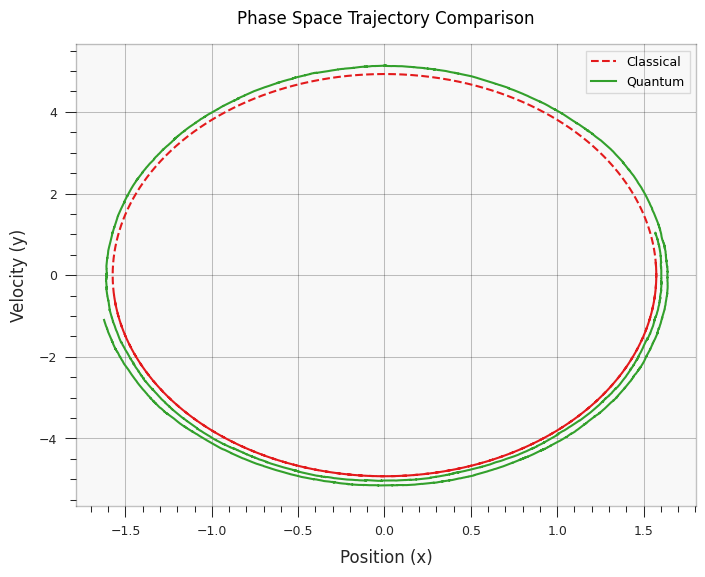

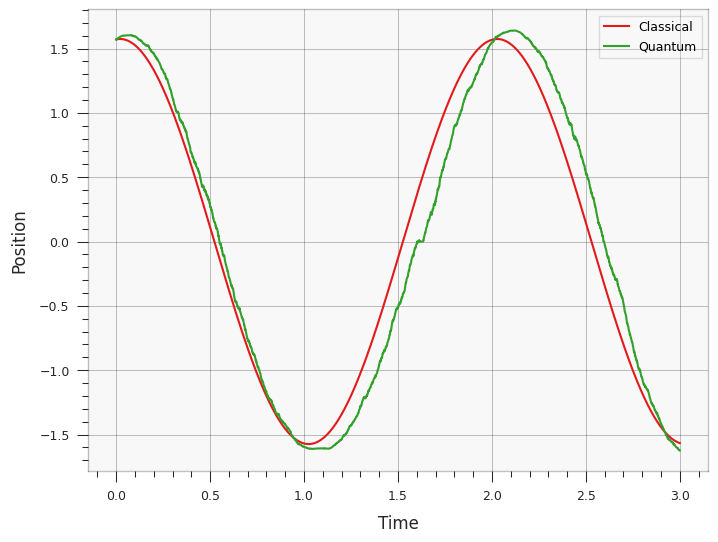

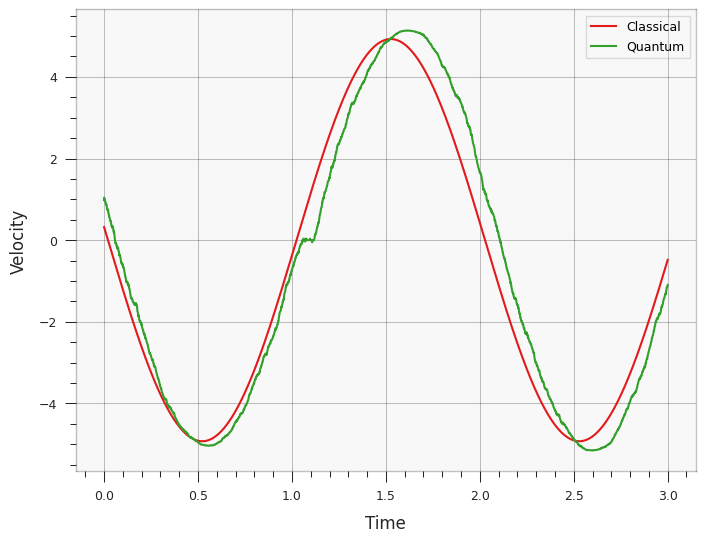

In [22]:

# Plot phase space trajectory
plt.figure(figsize=(8, 6))
plt.plot(positions_cl, velocities_cl, label='Classical', linestyle='--')
plt.plot(positions_q, velocities_q, label='Quantum')
plt.xlabel('Position (x)')
plt.ylabel('Velocity (y)')
plt.title('Phase Space Trajectory Comparison')
plt.legend()
plt.grid(True)
plt.show()

# Plot time series for comparison
plt.figure(figsize=(8, 6))
# plt.subplot(1, 2, 1)
plt.plot(t_values, positions_cl, label='Classical')
plt.plot(t_values, positions_q, label='Quantum')
plt.xlabel('Time')
plt.ylabel('Position')
plt.legend()
plt.grid(True)

plt.figure(figsize=(8, 6))
# plt.subplot(1, 2, 2)
plt.plot(t_values, velocities_cl, label='Classical')
plt.plot(t_values, velocities_q, label='Quantum')
plt.xlabel('Time')
plt.ylabel('Velocity')
plt.legend()
plt.grid(True)
plt.show()

## Non-linear

In [ ]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import XGate, ZGate
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

dt = 0.001
w2 = 9.8
w = np.sqrt(w2)
x0 = np.pi/2  # Reducido para mejor aproximación
y0 = 1.0 / w
n_steps = 3142
shots = 25000

def circuit(theta_init, x_current):
    qc = QuantumCircuit(3)
    qc.ry(theta_init, 1)
    
    if abs(x_current) > 1e-6:
        sin_approx = x_current - (x_current**3) / 6 - (x_current**5) / 120
        effective_w2 = w2 * sin_approx/x_current
    else:
        effective_w2 = w2
    effective_w = np.sqrt(effective_w2)
    
    dt_param = dt * effective_w
    b = 0.0
    c = dt_param
    c0 = 1.0
    c1 = np.abs(b)
    c2 = c
    alpha_lcu = c0 + c1 + c2
    p0 = c0 / alpha_lcu
    p1 = c1 / alpha_lcu
    p2 = c2 / alpha_lcu
    theta_q0 = 2 * np.arcsin(np.sqrt(p2))
    
    qc.ry(theta_q0, 0)
    qc.x(2)
    ccrx = XGate().control(num_ctrl_qubits=2, ctrl_state='11')
    qc.append(ccrx, [0, 2, 1])
    ccrz = ZGate().control(num_ctrl_qubits=2, ctrl_state='11')
    qc.append(ccrz, [0, 2, 1])
    qc.x(2)
    qc.ry(-theta_q0, 0)
    
    return qc, alpha_lcu

def next_step(x_current, y_current):
    norm_v = np.sqrt(x_current**2 + y_current**2)
    if norm_v == 0:
        return 0, 0
    theta_init = 2 * np.arctan2(y_current, x_current)
    
    qc, alpha_lcu = circuit(theta_init, x_current)
    
    qc_z = qc.copy()
    qc_z.measure_all()
    
    qc_x = qc.copy()
    qc_x.h(1)
    qc_x.measure_all()
    
    backend = AerSimulator()
    transpiled_circuits = transpile([qc_z, qc_x], backend, optimization_level=3)
    job = backend.run(transpiled_circuits, shots=shots)
    results = job.result()
    
    counts_z = results.get_counts(0)
    c000 = counts_z.get('000', 0)
    c010 = counts_z.get('010', 0)
    succ_z = c000 + c010
    if succ_z < 50:
        return x_current, y_current
    p_succ = succ_z / shots
    print(f"Paso: {len(trajectory)//2}, p_succ: {p_succ}")
    cond_p0 = c000 / succ_z
    cond_p1 = c010 / succ_z
    
    counts_x = results.get_counts(1)
    c000_x = counts_x.get('000', 0)
    c010_x = counts_x.get('010', 0)
    succ_x = c000_x + c010_x
    if succ_x < 50:
        return x_current, y_current
    cond_px = c000_x / succ_x
    x_exp = 2 * cond_px - 1
    
    abs_a = np.sqrt(cond_p0)
    abs_b = np.sqrt(cond_p1)
    computed_ab = x_exp / 2
    rel_sign = 1 if computed_ab >= 0 else -1
    a = abs_a
    b = rel_sign * abs_b
    
    scaling = alpha_lcu * norm_v * np.sqrt(p_succ)
    x_candidate1 = a * scaling
    y_candidate1 = b * scaling
    x_candidate2 = -a * scaling
    y_candidate2 = -b * scaling
    
    dot1 = x_candidate1 * x_current + y_candidate1 * y_current
    dot2 = x_candidate2 * x_current + y_candidate2 * y_current
    
    if dot1 >= dot2:
        return x_candidate1, y_candidate1
    else:
        return x_candidate2, y_candidate2

trajectory = []
x_current = x0
y_current = y0
trajectory.extend([x_current, y_current])

step = 0
while step < n_steps:
    x_new, y_new = next_step(x_current, y_current)
    trajectory.extend([x_new, y_new])
    x_current = x_new
    y_current = y_new
    step += 1

for i in range(1, len(trajectory), 2):
    trajectory[i] *= w

time = np.arange(0, len(trajectory)//2 * dt, dt)
xs = trajectory[::2]
ys = trajectory[1::2]


Paso: 1, p_succ: 0.99536
Paso: 2, p_succ: 0.99552
Paso: 3, p_succ: 0.99588
Paso: 4, p_succ: 0.99576
Paso: 5, p_succ: 0.99496
Paso: 6, p_succ: 0.99492
Paso: 7, p_succ: 0.9956
Paso: 8, p_succ: 0.9952
Paso: 9, p_succ: 0.99576
Paso: 10, p_succ: 0.9954
Paso: 11, p_succ: 0.99488
Paso: 12, p_succ: 0.99568
Paso: 13, p_succ: 0.9954
Paso: 14, p_succ: 0.99564
Paso: 15, p_succ: 0.995
Paso: 16, p_succ: 0.99532
Paso: 17, p_succ: 0.9946
Paso: 18, p_succ: 0.99552
Paso: 19, p_succ: 0.99532
Paso: 20, p_succ: 0.99564
Paso: 21, p_succ: 0.99504
Paso: 22, p_succ: 0.99564
Paso: 23, p_succ: 0.99544
Paso: 24, p_succ: 0.99508
Paso: 25, p_succ: 0.99628
Paso: 26, p_succ: 0.9954
Paso: 27, p_succ: 0.9954
Paso: 28, p_succ: 0.99584
Paso: 29, p_succ: 0.99544
Paso: 30, p_succ: 0.99516
Paso: 31, p_succ: 0.9952
Paso: 32, p_succ: 0.99556
Paso: 33, p_succ: 0.99616
Paso: 34, p_succ: 0.99616
Paso: 35, p_succ: 0.9958
Paso: 36, p_succ: 0.99444
Paso: 37, p_succ: 0.99536
Paso: 38, p_succ: 0.99508
Paso: 39, p_succ: 0.99592
Paso: 

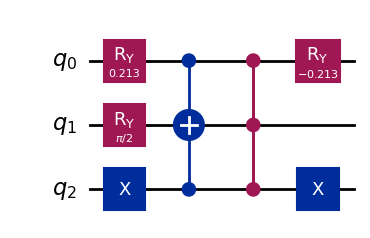

In [27]:
example_qc, _ = create_circuit(np.pi/2,np.pi/2)
example_qc.draw('mpl')

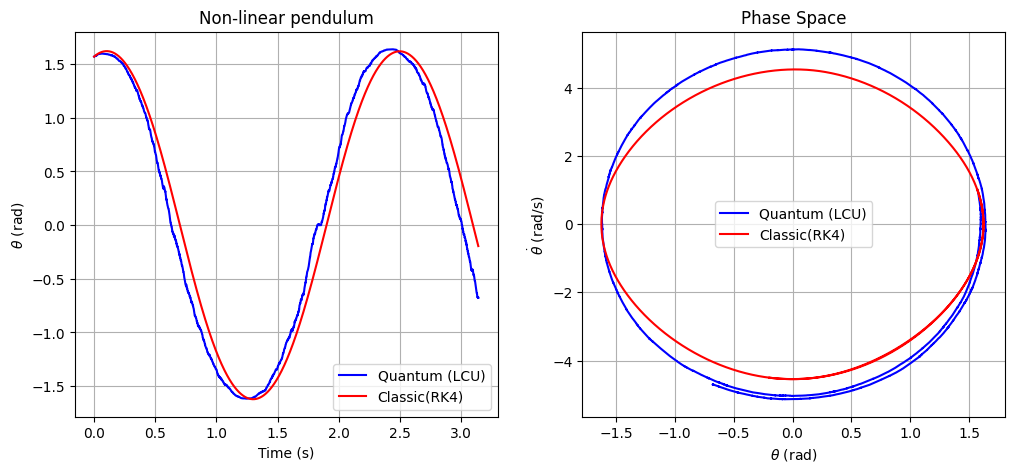

In [15]:
from scipy.integrate import solve_ivp

t_span = (0, n_steps * dt)
t_eval = np.arange(0, n_steps * dt, dt)

# Solución clásica con RK4
def pendulum_equations(t, state):
    theta, theta_dot = state
    return [theta_dot, -w2 * np.sin(theta)]

sol = solve_ivp(pendulum_equations, t_span, [x0, y0 * w], method='RK45', t_eval=t_eval)
theta_classical = sol.y[0]
theta_dot_classical = sol.y[1]

# Graficar
plt.figure(figsize=(12, 5))

# Ángulo vs. Tiempo
plt.subplot(1, 2, 1)
plt.plot(time, xs, label='Quantum (LCU)', color='blue')
plt.plot(t_eval, theta_classical, label='Classic(RK4)', color='red')
plt.xlabel('Time (s)')
plt.ylabel(r'$\theta$ (rad)')
plt.title('Non-linear pendulum')
plt.legend()
plt.grid(True)

# Espacio de fase
plt.subplot(1, 2, 2)
plt.plot(xs, ys, label='Quantum (LCU)', color='blue')
plt.plot(theta_classical, theta_dot_classical, label='Classic(RK4)', color='red')
plt.xlabel(r'$\theta$ (rad)')
plt.ylabel(r'$\dot{\theta}$ (rad/s)')
plt.title('Phase Space')
plt.legend()
plt.grid(True)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

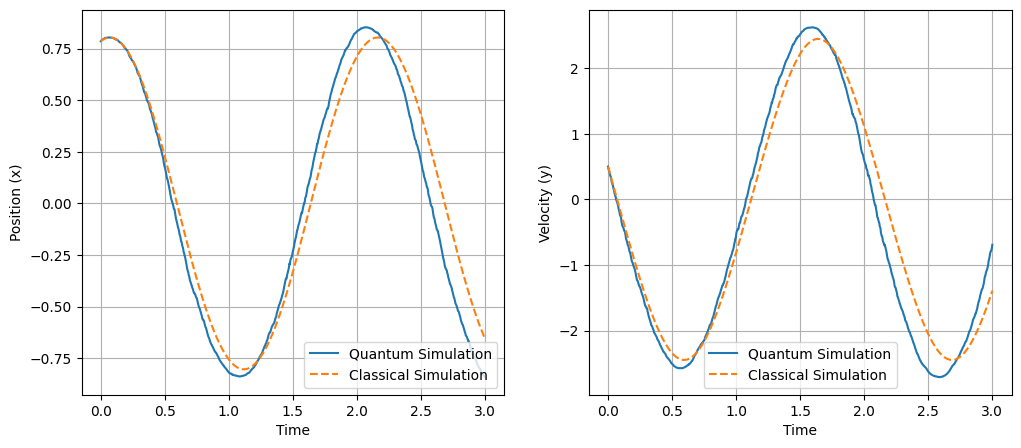

In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import XGate, ZGate
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
dt = 0.003
g = 9.8  # Acceleration due to gravity (m/s^2)
L = 1.0  # Length of pendulum (m)
w2 = g / L  # Square of the natural frequency for the linear case
w = np.sqrt(w2)
x0 = np.pi / 4  # Initial angle (radians)
y0 = 0.5  # Initial velocity (rad/s)
n_steps = 1000
shots = 15000

# Function to create the circuit with nonlinear term
def create_circuit(theta_init, x_current):
    qc = QuantumCircuit(3)
    # Prepare initial state in q1: RY(theta_init)
    qc.ry(theta_init, 1)
    # Nonlinear term: effective frequency
    if abs(x_current) > 1e-6:
        effective_w2 = w2 * np.sin(x_current) / x_current
    else:
        effective_w2 = w2
    effective_w = np.sqrt(effective_w2)
    
    # LCU parameters
    dt_param = dt * effective_w
    b = 0.0
    c = dt_param
    c0 = 1.0
    c1 = np.abs(b)
    c2 = c
    alpha_lcu = c0 + c1 + c2
    if alpha_lcu == 0:
        raise ValueError("LCU normalization factor alpha_lcu is zero")
    
    p0 = c0 / alpha_lcu
    p1 = c1 / alpha_lcu
    p2 = c2 / alpha_lcu
    # State preparation on ancillas q0 (p1=0 simplifies circuit)
    theta_q0 = 2 * np.arcsin(np.sqrt(p2))
    qc.ry(theta_q0, 0)
    # Select V (only U2 since p1=0)
    qc.x(2)
    ccrx = XGate().control(num_ctrl_qubits=2, ctrl_state='11')
    qc.append(ccrx, [0, 2, 1])
    ccrz = ZGate().control(num_ctrl_qubits=2, ctrl_state='11')
    qc.append(ccrz, [0, 2, 1])
    qc.x(2)
    # Inverse preparation
    qc.ry(-theta_q0, 0)
    return qc, alpha_lcu

# Simulation and extraction with measurements
def compute_next(x_current, y_current):
    norm_v = np.sqrt(x_current**2 + y_current**2)
    if norm_v < 1e-10:
        print("Warning: State norm is near zero, returning current state")
        return x_current, y_current
    theta_init = 2 * np.arctan2(y_current, x_current)
    qc, alpha_lcu = create_circuit(theta_init, x_current)
    
    # Prepare circuits for Z and X basis
    qc_z = qc.copy()
    qc_z.measure_all()
    
    qc_x = qc.copy()
    qc_x.h(1)
    qc_x.measure_all()
    
    # Run simulations
    backend = AerSimulator()
    transpiled_circuits = transpile([qc_z, qc_x], backend, optimization_level=3)
    job = backend.run(transpiled_circuits, shots=shots)
    results = job.result()
    
    # Z basis results
    counts_z = results.get_counts(0)
    c000 = counts_z.get('000', 0)
    c010 = counts_z.get('010', 0)
    succ_z = c000 + c010
    if succ_z < 50:
        print(f"Warning: Too few successful Z measurements ({succ_z}), returning current state")
        return x_current, y_current
    p_succ = succ_z / shots
    cond_p0 = c000 / succ_z
    cond_p1 = c010 / succ_z
    
    # X basis results
    counts_x = results.get_counts(1)
    c000_x = counts_x.get('000', 0)
    c010_x = counts_x.get('010', 0)
    succ_x = c000_x + c010_x
    if succ_x < 50:
        print(f"Warning: Too few successful X measurements ({succ_x}), returning current state")
        return x_current, y_current
    cond_px = c000_x / succ_x
    x_exp = 2 * cond_px - 1
    # Reconstruct amplitudes
    abs_a = np.sqrt(cond_p0)
    abs_b = np.sqrt(cond_p1)
    computed_ab = x_exp / 2
    rel_sign = 1 if computed_ab >= 0 else -1
    a = abs_a
    b = rel_sign * abs_b
    scaling = alpha_lcu * norm_v * np.sqrt(p_succ)
    x_candidate1 = a * scaling
    y_candidate1 = b * scaling
    x_candidate2 = -a * scaling
    y_candidate2 = -b * scaling
    dot1 = x_candidate1 * x_current + y_candidate1 * y_current
    dot2 = x_candidate2 * x_current + y_candidate2 * y_current
    if dot1 >= dot2:
        return x_candidate1, y_candidate1
    else:
        return x_candidate2, y_candidate2

# Compute trajectory (quantum)
trajectory = []
x_current = x0
y_current = y0 / w  # Scale to dimensionless
trajectory.extend([x_current, y_current])
for step in range(n_steps):
    print(step)
    x_new, y_new = compute_next(x_current, y_current)
    
    trajectory.extend([x_new, y_new])
    x_current = x_new
    y_current = y_new

# Rescale y for physical units
for i in range(1, len(trajectory), 2):
    trajectory[i] *= w

# Extract positions and velocities (quantum)
time = np.arange(0, len(trajectory) // 2 * dt, dt)
xs = trajectory[::2]
ys = trajectory[1::2]

# Classical simulation for the nonlinear pendulum
def pendulum_nonlinear(y0, x0, g, L, t):
    def dxdt(x, t):
        return [x[1], -(g / L) * np.sin(x[0])]
    
    # Solve for the pendulum's motion
    sol = odeint(dxdt, [x0, y0], t)
    return sol[:, 0], sol[:, 1]

# Classical simulation
x_classical, y_classical = pendulum_nonlinear(y0, x0, g, L, time)

# Plot time series (comparison quantum vs classical)
plt.figure(figsize=(12, 5))
# Position plot
plt.subplot(1, 2, 1)
plt.plot(time, xs, label='Quantum Simulation')
plt.plot(time, x_classical, label='Classical Simulation', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Position (x)')
plt.legend()
plt.grid(True)
# Velocity plot
plt.subplot(1, 2, 2)
plt.plot(time, ys, label='Quantum Simulation')
plt.plot(time, y_classical, label='Classical Simulation', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Velocity (y)')
plt.legend()
plt.grid(True)
plt.show()

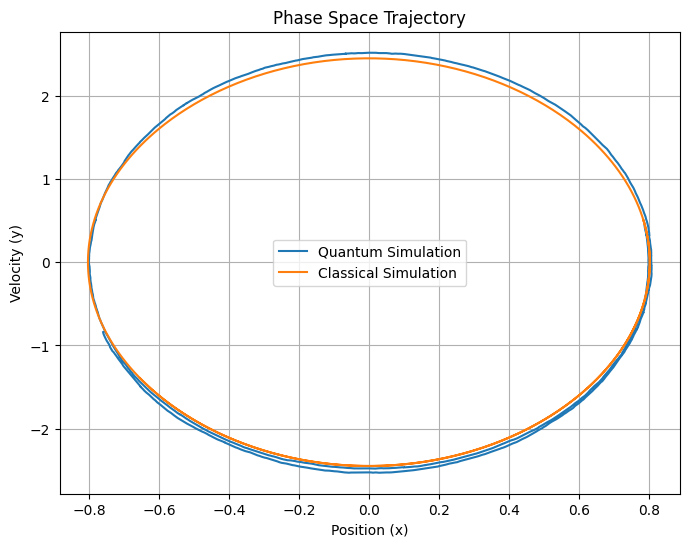

In [31]:
plt.figure(figsize=(8, 6))
plt.plot(xs, ys, label='Quantum Simulation')
plt.plot(x_classical, y_classical, label='Classical Simulation')
plt.xlabel('Position (x)')
plt.ylabel('Velocity (y)')
plt.title('Phase Space Trajectory')
plt.legend()
plt.grid(True)
plt.show()

# Comprobación

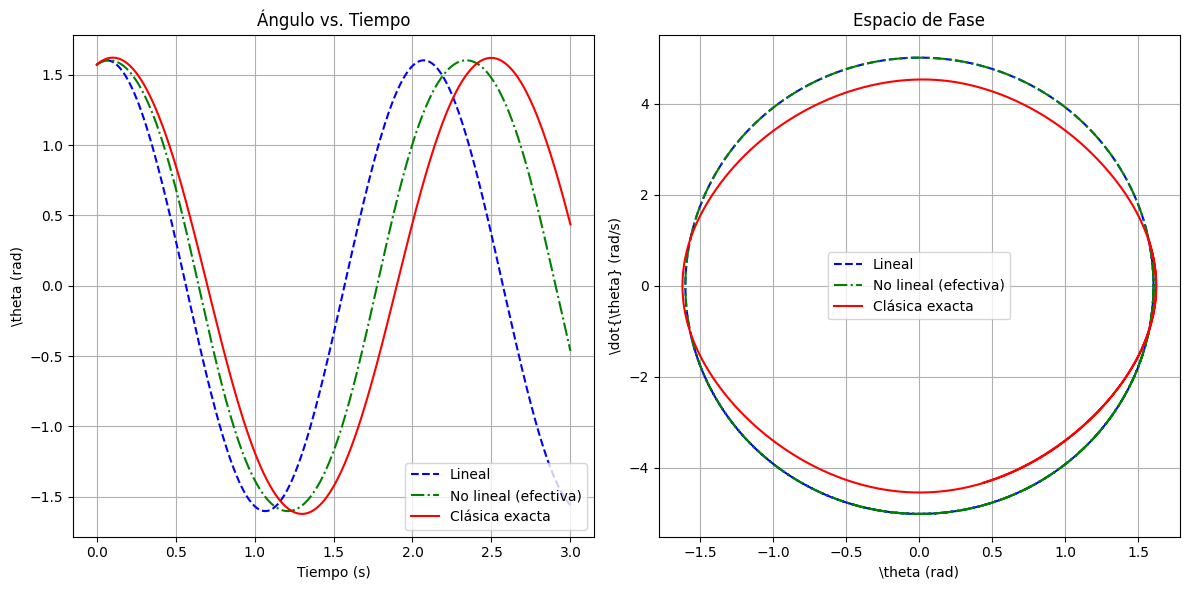

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parámetros (mismos que en tu código)
dt = 0.001
w2 = 9.8
w = np.sqrt(w2)
x0 = np.pi/2 
y0 = 1.0 / w
n_steps = 3000
t_span = (0, n_steps * dt)
t_eval = np.arange(0, (n_steps + 1) * dt, dt)

# Función de actualización general
def compute_next_general(x_current, y_current, use_nonlinear=True):
    norm_v = np.sqrt(x_current**2 + y_current**2)
    if norm_v == 0:
        return 0, 0
    if use_nonlinear and abs(x_current) > 1e-6:
        sin_approx = x_current - (x_current**3) / 6 - (x_current**5) / 120
        effective_w2 = w2 * (np.sin(x_current) / x_current)
    else:
        effective_w2 = w2
    effective_w = np.sqrt(effective_w2)
    c = dt * effective_w
    x_new = x_current + c * y_current
    y_new = -c * x_current + y_current
    scaling = np.sqrt(1 + c**2)
    return x_new / scaling, y_new / scaling

# Trayectoria lineal (sin no linealidad)
trajectory_linear = [x0, y0]
x_current, y_current = x0, y0
for _ in range(n_steps):
    x_new, y_new = compute_next_general(x_current, y_current, use_nonlinear=False)
    trajectory_linear.extend([x_new, y_new])
    x_current, y_current = x_new, y_new
xs_linear = np.array(trajectory_linear[::2])
ys_linear = np.array(trajectory_linear[1::2]) * w

# Trayectoria no lineal (con frecuencia efectiva)
trajectory_nl = [x0, y0]
x_current, y_current = x0, y0
for _ in range(n_steps):
    x_new, y_new = compute_next_general(x_current, y_current, use_nonlinear=True)
    trajectory_nl.extend([x_new, y_new])
    x_current, y_current = x_new, y_new
xs_nl = np.array(trajectory_nl[::2])
ys_nl = np.array(trajectory_nl[1::2]) * w

# Solución clásica exacta
def pendulum_equations(t, state):
    theta, theta_dot = state
    return [theta_dot, -w2 * np.sin(theta)]
sol = solve_ivp(pendulum_equations, t_span, [x0, y0 * w], method='RK45', t_eval=t_eval)
theta_classical = sol.y[0]
theta_dot_classical = sol.y[1]

# Graficar
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(t_eval, xs_linear, label='Lineal', color='blue', linestyle='--')
plt.plot(t_eval, xs_nl, label='No lineal (efectiva)', color='green', linestyle='-.')
plt.plot(t_eval, theta_classical, label='Clásica exacta', color='red')
plt.xlabel('Tiempo (s)')
plt.ylabel(r'\theta (rad)')
plt.title('Ángulo vs. Tiempo')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(xs_linear, ys_linear, label='Lineal', color='blue', linestyle='--')
plt.plot(xs_nl, ys_nl, label='No lineal (efectiva)', color='green', linestyle='-.')
plt.plot(theta_classical, theta_dot_classical, label='Clásica exacta', color='red')
plt.xlabel(r'\theta (rad)')
plt.ylabel(r'\dot{\theta} (rad/s)')
plt.title('Espacio de Fase')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Paso: 1, p_succ: 0.9677333333333333
Paso: 2, p_succ: 0.9622
Paso: 3, p_succ: 0.9604666666666667
Paso: 4, p_succ: 0.9619333333333333
Paso: 5, p_succ: 0.9611333333333333
Paso: 6, p_succ: 0.9617333333333333
Paso: 7, p_succ: 0.9620666666666666
Paso: 8, p_succ: 0.9624666666666667
Paso: 9, p_succ: 0.9619333333333333
Paso: 10, p_succ: 0.9614
Paso: 11, p_succ: 0.963
Paso: 12, p_succ: 0.9592666666666667
Paso: 13, p_succ: 0.961
Paso: 14, p_succ: 0.9636666666666667
Paso: 15, p_succ: 0.96
Paso: 16, p_succ: 0.964
Paso: 17, p_succ: 0.9619333333333333
Paso: 18, p_succ: 0.9608
Paso: 19, p_succ: 0.9619333333333333
Paso: 20, p_succ: 0.9616
Paso: 21, p_succ: 0.9612
Paso: 22, p_succ: 0.9653333333333334
Paso: 23, p_succ: 0.9612
Paso: 24, p_succ: 0.9619333333333333
Paso: 25, p_succ: 0.9612666666666667
Paso: 26, p_succ: 0.9636666666666667
Paso: 27, p_succ: 0.9634666666666667
Paso: 28, p_succ: 0.963
Paso: 29, p_succ: 0.9605333333333334
Paso: 30, p_succ: 0.9630666666666666
Paso: 31, p_succ: 0.9643333333333334


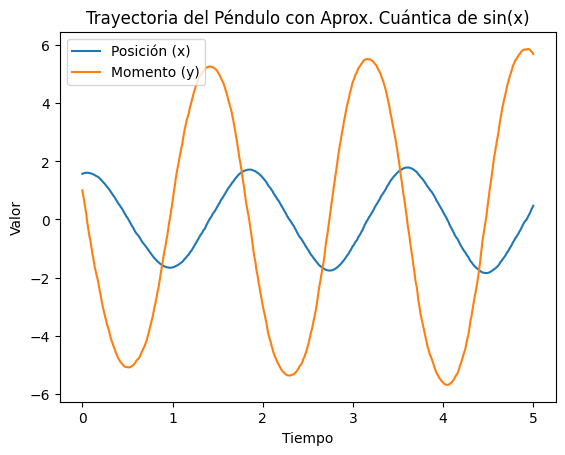

In [ ]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import XGate, ZGate
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, Pauli
import matplotlib.pyplot as plt

# Parámetros del péndulo
dt = 0.005
w2 = 9.8
w = np.sqrt(w2)
x0 = np.pi/2  # Reducido para mejor aproximación
y0 = 1.0 / w
n_steps = 1000
shots = 15000

# Parámetros para la aproximación cuántica (del segundo código)
scale = 10.0  # Ajusta según el rango de x_current; para x ~ pi/2, 10 es suficiente para evitar clipping

# Funciones adaptadas del segundo código
def normalize(val):
    norm_val = val / scale
    if abs(norm_val) > 1:
        print(f"Warning: |norm_val| > 1 ({norm_val}), clipping for arcsin")
        norm_val = np.clip(norm_val, -1, 1)
    return norm_val

def get_square(norm_val):
    u = np.clip(norm_val, -1, 1)
    theta = 2 * np.arcsin(u)
    qc = QuantumCircuit(1)
    qc.rx(theta, 0)  # RX(theta) |0> da <Z> = cos(theta) = 1 - 2 u^2
    
    # Usamos Statevector para exactitud y velocidad en la approx de sin
    state = Statevector(qc)
    z_exp = state.expectation_value(Pauli('Z')).real
    
    sq = (1 - z_exp) / 2
    return sq

def compute_product(norm_a, norm_b):
    a_sq = get_square(norm_a)
    b_sq = get_square(norm_b)
    ab_sum_sq = get_square(norm_a + norm_b)
    ab_norm = (ab_sum_sq - a_sq - b_sq) / 2
    return ab_norm

def create_circuit(theta_init, x_current):
    qc = QuantumCircuit(3)
    qc.ry(theta_init, 1)
    
    if abs(x_current) > 1e-6:
        x_norm = normalize(x_current)
        
        # Computar x^2 normalizado: (x/scale)^2
        x2_norm = get_square(x_norm)
        
        # Computar x^3 normalizado: (x/scale)^3 = compute_product(x_norm, x2_norm)
        x3_norm = compute_product(x_norm, x2_norm)
        x3 = x3_norm * (scale ** 3)
        
        # Computar x^4 normalizado: (x/scale)^4 = get_square(x2_norm)
        x4_norm = get_square(x2_norm)
        
        # Computar x^5 normalizado: (x/scale)^5 = compute_product(x_norm, x4_norm)
        x5_norm = compute_product(x_norm, x4_norm)
        x5 = x5_norm * (scale ** 5)
        
        # Aproximación de sin(x) con corrección: x - x^3/6 + x^5/120
        sin_approx = x_current - x3 / 6 + x5 / 120
        
        effective_w2 = w2 * (sin_approx/x_current)
    else:
        effective_w2 = w2
    
    effective_w = np.sqrt(effective_w2)
    
    dt_param = dt * effective_w
    b = 0.0
    c = dt_param
    c0 = 1.0
    c1 = np.abs(b)
    c2 = c
    alpha_lcu = c0 + c1 + c2
    p0 = c0 / alpha_lcu
    p1 = c1 / alpha_lcu
    p2 = c2 / alpha_lcu
    theta_q0 = 2 * np.arcsin(np.sqrt(p2))
    
    qc.ry(theta_q0, 0)
    qc.x(2)
    ccrx = XGate().control(num_ctrl_qubits=2, ctrl_state='11')
    qc.append(ccrx, [0, 2, 1])
    ccrz = ZGate().control(num_ctrl_qubits=2, ctrl_state='11')
    qc.append(ccrz, [0, 2, 1])
    qc.x(2)
    qc.ry(-theta_q0, 0)
    
    return qc, alpha_lcu

def compute_next(x_current, y_current):
    norm_v = np.sqrt(x_current**2 + y_current**2)
    if norm_v == 0:
        return 0, 0
    theta_init = 2 * np.arctan2(y_current, x_current)
    
    qc, alpha_lcu = create_circuit(theta_init, x_current)
    
    qc_z = qc.copy()
    qc_z.measure_all()
    
    qc_x = qc.copy()
    qc_x.h(1)
    qc_x.measure_all()
    
    backend = AerSimulator()
    transpiled_circuits = transpile([qc_z, qc_x], backend, optimization_level=3)
    job = backend.run(transpiled_circuits, shots=shots)
    results = job.result()
    
    counts_z = results.get_counts(0)
    c000 = counts_z.get('000', 0)
    c010 = counts_z.get('010', 0)
    succ_z = c000 + c010
    if succ_z < 50:
        return x_current, y_current
    p_succ = succ_z / shots
    print(f"Paso: {len(trajectory)//2}, p_succ: {p_succ}")
    cond_p0 = c000 / succ_z
    cond_p1 = c010 / succ_z
    
    counts_x = results.get_counts(1)
    c000_x = counts_x.get('000', 0)
    c010_x = counts_x.get('010', 0)
    succ_x = c000_x + c010_x
    if succ_x < 50:
        return x_current, y_current
    cond_px = c000_x / succ_x
    x_exp = 2 * cond_px - 1
    
    abs_a = np.sqrt(cond_p0)
    abs_b = np.sqrt(cond_p1)
    computed_ab = x_exp / 2
    rel_sign = 1 if computed_ab >= 0 else -1
    a = abs_a
    b = rel_sign * abs_b
    
    scaling = alpha_lcu * norm_v * np.sqrt(p_succ)
    x_candidate1 = a * scaling
    y_candidate1 = b * scaling
    x_candidate2 = -a * scaling
    y_candidate2 = -b * scaling
    
    dot1 = x_candidate1 * x_current + y_candidate1 * y_current
    dot2 = x_candidate2 * x_current + y_candidate2 * y_current
    
    if dot1 >= dot2:
        return x_candidate1, y_candidate1
    else:
        return x_candidate2, y_candidate2

trajectory = []
x_current = x0
y_current = y0
trajectory.extend([x_current, y_current])
step = 0
while step < n_steps:
    x_new, y_new = compute_next(x_current, y_current)
    trajectory.extend([x_new, y_new])
    x_current = x_new
    y_current = y_new
    step += 1

for i in range(1, len(trajectory), 2):
    trajectory[i] *= w

time = np.arange(0, len(trajectory)//2 * dt, dt)
xs = trajectory[::2]
ys = trajectory[1::2]

# Visualización (opcional, como en el original)
plt.plot(time, xs, label='Posición (x)')
plt.plot(time, ys, label='Momento (y)')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.title('Trayectoria del Péndulo con Aprox. Cuántica de sin(x)')
plt.legend()
plt.show()

In [ ]:
from qiskit_aer import AerSimulator
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import XGate, ZGate

dt = 0.003
w2 = 9.8
w = np.sqrt(w2)  # For classical solution
x0 = np.pi / 4
y0 = 1.0
n_steps = 1000
shots = 25000  # Number of shots for measurements

# Function to create the circuit
def create_circuit(theta_init):
    qc = QuantumCircuit(3)
    # Prepare initial state in q1: RY(theta_init)
    qc.ry(theta_init, 1)
    # LCU parameters for general omega
    b = dt * (1 - w2) / 2
    c = dt * (1 + w2) / 2
    c0 = 1.0
    c1 = np.abs(b)
    c2 = c
    alpha_lcu = c0 + c1 + c2
    if alpha_lcu == 0:
        raise ValueError("LCU normalization factor alpha_lcu is zero")
   
    sign_x = np.sign(b) if b != 0 else 1
    p0 = c0 / alpha_lcu
    p1 = c1 / alpha_lcu
    p2 = c2 / alpha_lcu
    # State preparation on ancillas q0 and q2
    theta_q0 = 2 * np.arcsin(np.sqrt(p2))
    qc.ry(theta_q0, 0)
    p_sum = p0 + p1
    theta_q2 = 2 * np.arcsin(np.sqrt(p1 / p_sum) if p_sum > 0 else 0)
    qc.x(0)
    qc.cry(theta_q2, 0, 2)
    qc.x(0)
    # Select V
    # U1 on |01> (q0=0, q2=1): X or -X (= Z X Z)
    qc.x(0)
    if sign_x == 1:
        ccrx = XGate().control(num_ctrl_qubits=2, ctrl_state='11')
        qc.append(ccrx, [0, 2, 1])
    else:
        ccrz = ZGate().control(num_ctrl_qubits=2, ctrl_state='11')
        ccrx = XGate().control(num_ctrl_qubits=2, ctrl_state='11')
        qc.append(ccrz, [0, 2, 1])
        qc.append(ccrx, [0, 2, 1])
        qc.append(ccrz, [0, 2, 1])
    qc.x(0)
    # U2 on |10> (q0=1, q2=0): Z X
    qc.x(2)
    ccrx = XGate().control(num_ctrl_qubits=2, ctrl_state='11')
    qc.append(ccrx, [0, 2, 1])
    ccrz = ZGate().control(num_ctrl_qubits=2, ctrl_state='11')
    qc.append(ccrz, [0, 2, 1])
    qc.x(2)
    # Inverse preparation
    qc.x(0)
    qc.cry(-theta_q2, 0, 2)
    qc.x(0)
    qc.ry(-theta_q0, 0)
    return qc, alpha_lcu

# Simulation and extraction with QST (measurements in X, Y, Z bases with post-selection)
def compute_next(x_current, y_current):
    norm_v = np.sqrt(x_current**2 + y_current**2)
    if norm_v < 1e-10:  # Avoid division by zero
        print("Warning: State norm is near zero, returning current state")
        return x_current, y_current
    theta_init = 2 * np.arctan2(y_current, x_current)
    qc, alpha_lcu = create_circuit(theta_init)
    backend = AerSimulator()
    
    # Z basis measurement for <Z>
    qc_z = qc.copy()
    qc_z.measure_all()
    result_z = backend.run(qc_z, shots=shots).result()
    counts_z = result_z.get_counts()
    c000 = counts_z.get('000', 0)
    c010 = counts_z.get('010', 0)
    succ_z = c000 + c010
    if succ_z < 10:  # Avoid poor statistics
        print("Warning: Too few successful Z measurements, returning current state")
        return x_current, y_current
    p_succ_z = succ_z / shots
    cond_p0 = c000 / succ_z  # P(0|post-select)
    cond_p1 = c010 / succ_z  # P(1|post-select)
    rz = 2 * cond_p0 - 1  # <Z> in post-selected subspace
    
    # X basis measurement for <X>
    qc_x = qc.copy()
    qc_x.h(1)  # Hadamard on q1 for X basis
    qc_x.measure_all()
    result_x = backend.run(qc_x, shots=shots).result()
    counts_x = result_x.get_counts()
    c000_x = counts_x.get('000', 0)
    c010_x = counts_x.get('010', 0)
    succ_x = c000_x + c010_x
    if succ_x < 10:
        print("Warning: Too few successful X measurements, returning current state")
        return x_current, y_current
    p_succ_x = succ_x / shots
    cond_px = c000_x / succ_x  # P(+|post-select)
    rx = 2 * cond_px - 1  # <X> = P(+) - P(-)
    
    # Y basis measurement for <Y>
    qc_y = qc.copy()
    qc_y.sdg(1)  # S dagger for Y basis
    qc_y.h(1)    # Hadamard
    qc_y.measure_all()
    result_y = backend.run(qc_y, shots=shots).result()
    counts_y = result_y.get_counts()
    c000_y = counts_y.get('000', 0)
    c010_y = counts_y.get('010', 0)
    succ_y = c000_y + c010_y
    if succ_y < 10:
        print("Warning: Too few successful Y measurements, returning current state")
        return x_current, y_current
    p_succ_y = succ_y / shots
    cond_py = c000_y / succ_y  # P(+y|post-select)
    ry = 2 * cond_py - 1  # <Y> = P(+y) - P(-y)
    
    # Average post-selection probability for scaling (QST uses all bases)
    p_succ = np.mean([p_succ_z, p_succ_x, p_succ_y])
    
    # Optional: Warn if |<Y>| is significant (should be ~0 for real state)
    if abs(ry) > 0.01:  # Threshold for noise
        print(f"Warning: Non-zero <Y> = {ry:.4f} detected (possible noise or phase); using real projection.")
    
    # Reconstruct amplitudes using QST (Bloch vector for post-selected state)
    # For real amplitudes (as per LCU design), use <Z> for populations, <X> for real off-diagonal
    # <Y> confirms ~0; ignore Im for continuity with real representation
    abs_a = np.sqrt(cond_p0)  # |alpha|^2 = (1 + rz)/2
    abs_b = np.sqrt(cond_p1)  # |beta|^2 = (1 - rz)/2
    computed_ab = rx / 2  # Re(alpha* beta) ≈ Re(a b) since real
    rel_sign = 1 if computed_ab >= 0 else -1
    
    # To incorporate <Y> more fully (project to real): adjust rel_sign if needed, but same as sign(rx)
    # For pure-state approx: beta_re = (rx / 2) / abs_a if abs_a > 1e-10 else rel_sign * abs_b
    # But keep consistent with original: b = rel_sign * abs_b (real projection)
    a = abs_a
    b = rel_sign * abs_b
    
    scaling = alpha_lcu * norm_v * np.sqrt(p_succ)
    x_candidate1 = a * scaling
    y_candidate1 = b * scaling
    x_candidate2 = -a * scaling
    y_candidate2 = -b * scaling
    
    # Choose based on continuity (dot product)
    dot1 = x_candidate1 * x_current + y_candidate1 * y_current
    dot2 = x_candidate2 * x_current + y_candidate2 * y_current
    if dot1 >= dot2:
        return x_candidate1, y_candidate1
    else:
        return x_candidate2, y_candidate2

# Compute trajectory
trajectory = [(x0, y0)]
x_current = x0
y_current = y0
for step in range(n_steps):
    print(step)
    x_new, y_new = compute_next(x_current, y_current)
    trajectory.append((x_new, y_new))
    x_current, y_current = x_new, y_new

# Extract positions and velocities
positions_q, velocities_q = zip(*trajectory)

# Compute classical trajectory (harmonic oscillator)
t_values = np.arange(0, (n_steps + 1) * dt, dt)
positions_cl = x0 * np.cos(w * t_values) + (y0 / w) * np.sin(w * t_values)
velocities_cl = y0 * np.cos(w * t_values) - w * x0 * np.sin(w * t_values)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

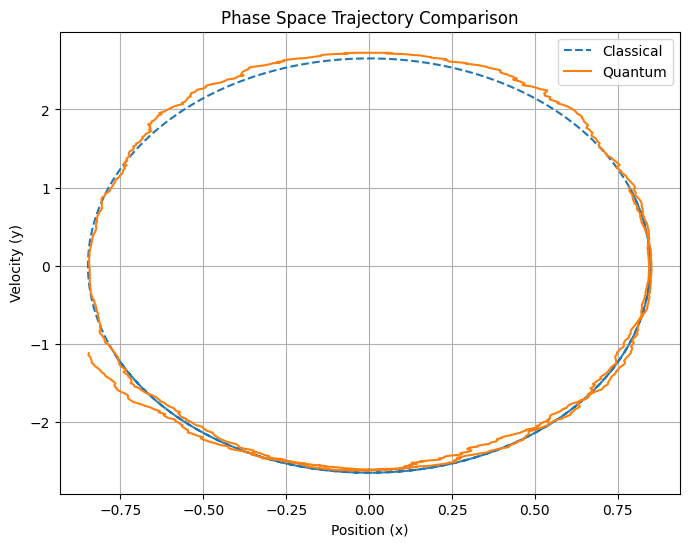

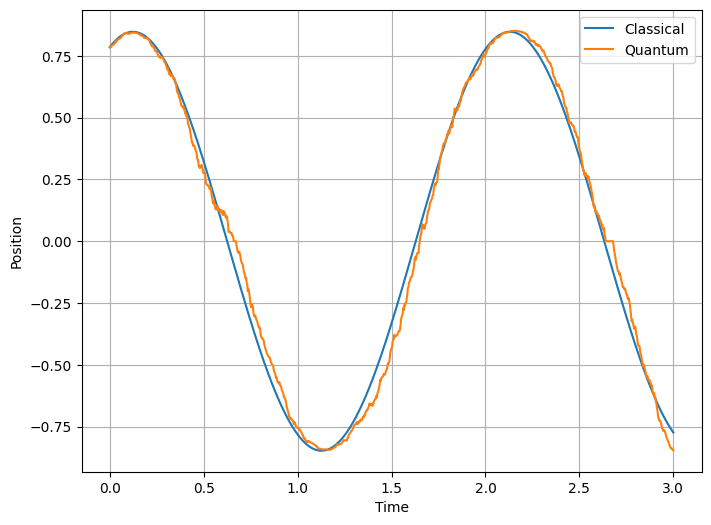

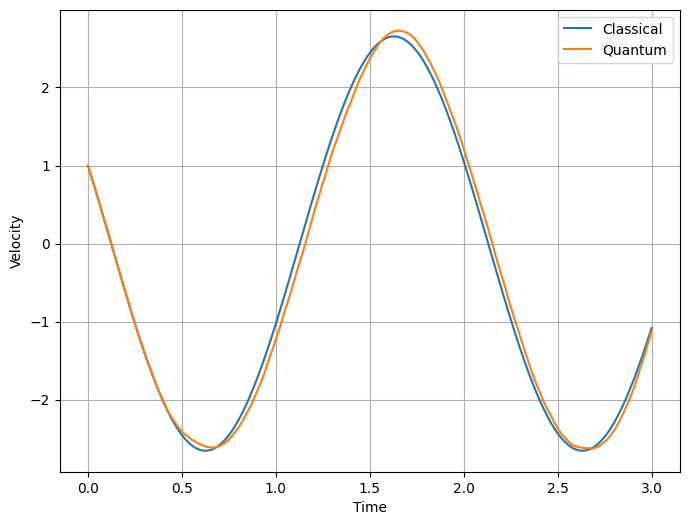

In [32]:
import matplotlib.pyplot as plt

# Compute classical trajectory (harmonic oscillator)
t_values = np.arange(0, (n_steps + 1) * dt, dt)
positions_cl = x0 * np.cos(w * t_values) + (y0 / w) * np.sin(w * t_values)
velocities_cl = y0 * np.cos(w * t_values) - w * x0 * np.sin(w * t_values)

# Plot phase space trajectory
plt.figure(figsize=(8, 6))
plt.plot(positions_cl, velocities_cl, label='Classical', linestyle='--')
plt.plot(positions_q, velocities_q, label='Quantum')
plt.xlabel('Position (x)')
plt.ylabel('Velocity (y)')
plt.title('Phase Space Trajectory Comparison')
plt.legend()
plt.grid(True)
plt.show()

# Plot time series for comparison
plt.figure(figsize=(8, 6))
# plt.subplot(1, 2, 1)
plt.plot(t_values, positions_cl, label='Classical')
plt.plot(t_values, positions_q, label='Quantum')
plt.xlabel('Time')
plt.ylabel('Position')
plt.legend()
plt.grid(True)

plt.figure(figsize=(8, 6))
# plt.subplot(1, 2, 2)
plt.plot(t_values, velocities_cl, label='Classical')
plt.plot(t_values, velocities_q, label='Quantum')
plt.xlabel('Time')
plt.ylabel('Velocity')
plt.legend()
plt.grid(True)
plt.show()